     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


Saving Huntington Disease Dataset.zip to Huntington Disease Dataset.zip
Dataset Loaded Successfully!

                             Patient_ID  Age     Sex Family_History  \
0  b2a49170-8561-4665-9371-2240b55dd87a   31    Male             No   
1  f5fae45d-8718-41c4-a957-6928f79f3c8e   33  Female            Yes   
2  66ab0567-050b-4d56-9ec4-b676309899a6   69    Male            Yes   
3  996a48e4-e841-418f-a539-5a7a86cd815d   66    Male            Yes   
4  d45c7ca8-7125-4aaa-8018-5bbc60d35a1f   43  Female            Yes   

   HTT_CAG_Repeat_Length Motor_Symptoms Cognitive_Decline  Chorea_Score  \
0                     67       Moderate            Severe          8.80   
1                     38         Severe          Moderate          3.24   
2                     37         Severe          Moderate          1.01   
3                     50           Mild            Severe          3.21   
4                     48       Moderate              Mild          2.31   

   Brain_Volume_Loss

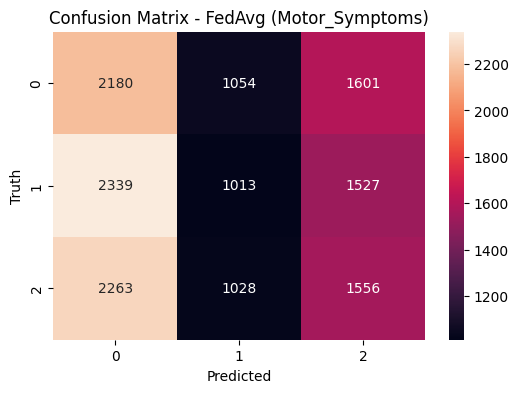


LIME Explanations (2 samples)
sample: 0 true: 1 pred: 0


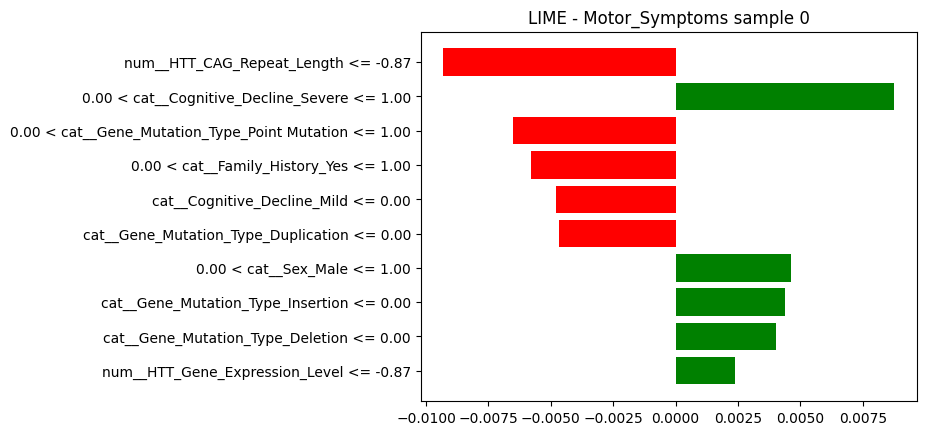

sample: 1 true: 1 pred: 0


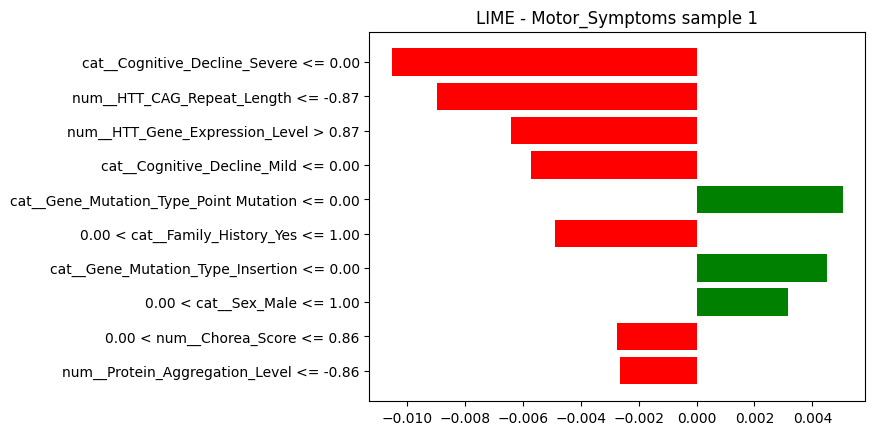


Training FedAvg + LIME for: Disease_Stage
round 1 test accuracy: 0.2544
round 2 test accuracy: 0.2533
round 3 test accuracy: 0.2565
round 4 test accuracy: 0.2542
round 5 test accuracy: 0.2555

Final Test Metrics
Accuracy: 0.2555
Precision: 0.2554
Recall: 0.2555
F1 Score: 0.2545


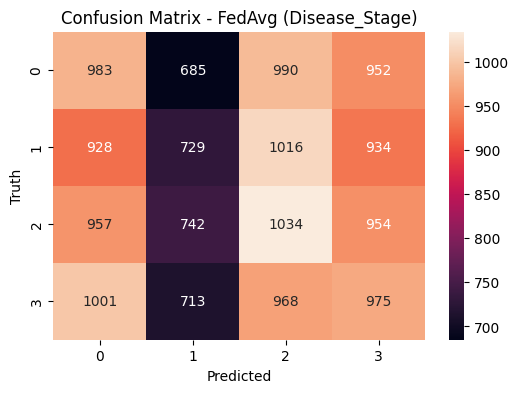


LIME Explanations (2 samples)
sample: 0 true: 2 pred: 0


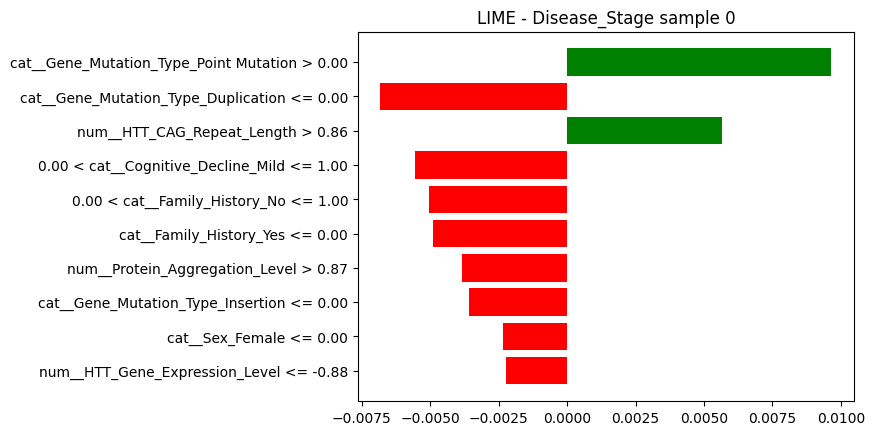

sample: 1 true: 3 pred: 3


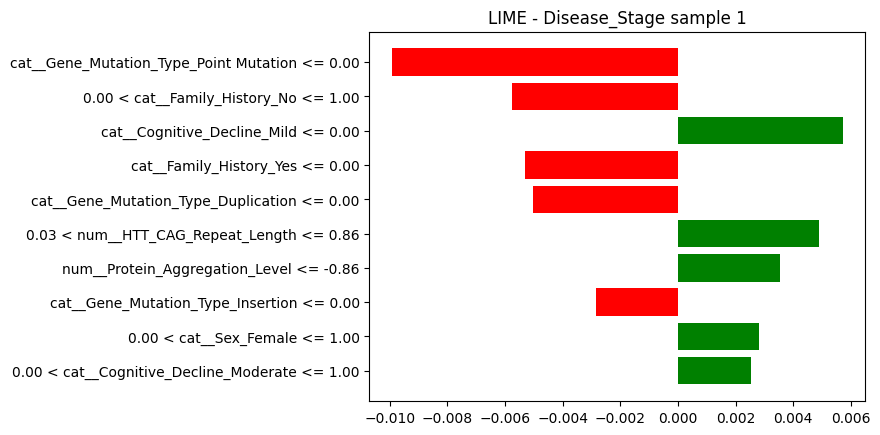


Training FedAvg + LIME for: Category
round 1 test accuracy: 0.5002
round 2 test accuracy: 0.5002
round 3 test accuracy: 0.5002
round 4 test accuracy: 0.5002
round 5 test accuracy: 0.5002

Final Test Metrics
Accuracy: 0.5002
Precision: 0.2502
Recall: 0.5002
F1 Score: 0.3336


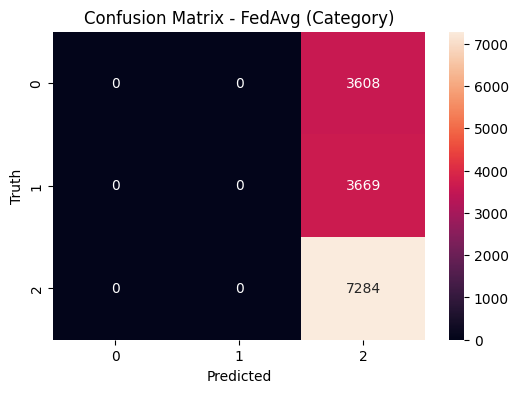


LIME Explanations (2 samples)
sample: 0 true: 2 pred: 2


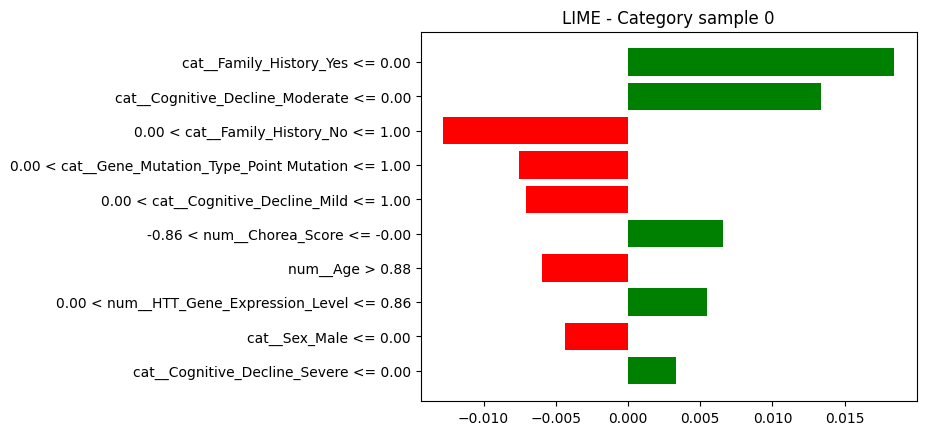

sample: 1 true: 2 pred: 2


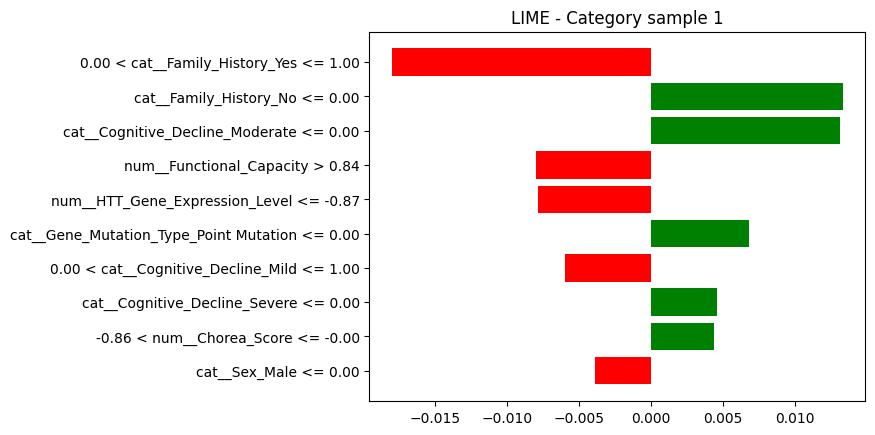


===== Comparison of Final Model Results =====
         Model          Target  Accuracy  Precision    Recall  F1 Score
0  FedAvg+LIME  Motor_Symptoms  0.326145   0.326984  0.326145  0.318445
1  FedAvg+LIME   Disease_Stage  0.255546   0.255444  0.255546  0.254535
2  FedAvg+LIME        Category  0.500240   0.250240  0.500240  0.333600

Per-Target Accuracy:
FedAvg+LIME - Motor_Symptoms: 32.61%
FedAvg+LIME - Disease_Stage: 25.55%
FedAvg+LIME - Category: 50.02%

Overall Dataset Accuracy (Average of all targets):
FedAvg+LIME: 36.06 %


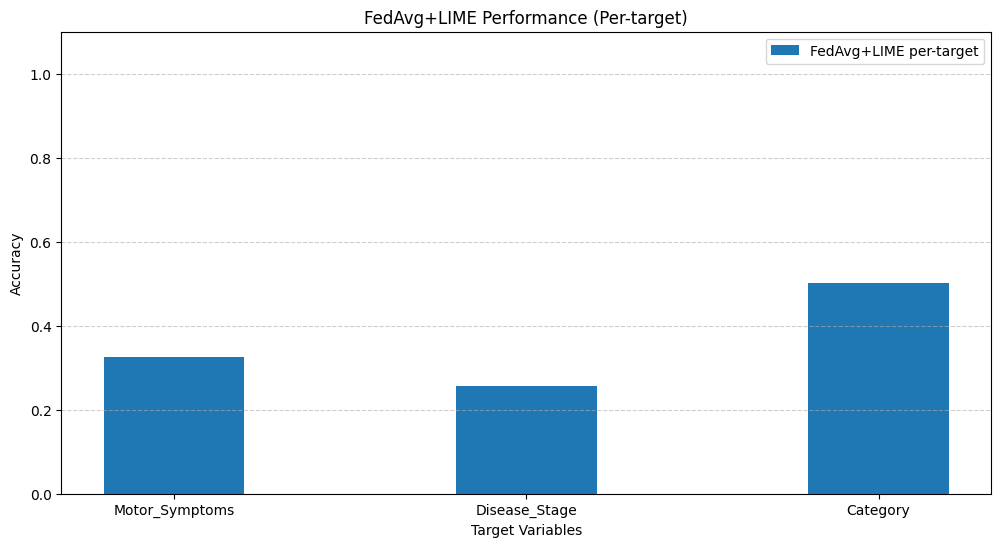

In [2]:
# install lime
!pip -q install lime

# libraries
import pandas as pd
import zipfile
import os
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import numpy as np

import tensorflow as tf

from lime.lime_tabular import LimeTabularExplainer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

tf.random.set_seed(42)
np.random.seed(42)

# upload and load dataset
uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall("/content/")

extracted_files = os.listdir("/content/")
csv_file = [f for f in extracted_files if f.endswith(".csv")][0]
csv_path = os.path.join("/content/", csv_file)

df = pd.read_csv(csv_path)
print("Dataset Loaded Successfully!\n")
print(df.head(), "\n")
print("Dataset Info:\n")
print(df.info(), "\n")

# cleaning
df = df.ffill()

df = df.drop(columns=[
    "Patient_ID",
    "Function",
    "Effect",
    "Gene/Factor",
    "Chromosome_Location",
    "Random_Protein_Sequence",
    "Random_Gene_Sequence"
], errors='ignore')

print("\nMissing values after cleaning:\n")
print(df.isnull().sum())

# show class counts
print("\nMotor_Symptoms Categories Count:")
print(df["Motor_Symptoms"].value_counts())
print("\nDisease_Stage Categories Count:")
print(df["Disease_Stage"].value_counts())
print("\nCategory (Final Diagnosis) Count:")
print(df["Category"].value_counts())

# model
def build_model(input_dim, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# fedavg helpers
def split_into_clients(X, y, num_clients=3):
    idx = np.arange(len(X))
    np.random.shuffle(idx)
    shards = np.array_split(idx, num_clients)
    return [(X[s], y[s]) for s in shards]

def get_weights(model):
    return [w.copy() for w in model.get_weights()]

def set_weights(model, weights):
    model.set_weights(weights)

def subtract_weights(new_w, old_w):
    return [nw - ow for nw, ow in zip(new_w, old_w)]

def add_weights(w, update):
    return [wi + ui for wi, ui in zip(w, update)]

def average_updates(updates):
    avg = []
    for layer in zip(*updates):
        avg.append(np.mean(layer, axis=0))
    return avg

def predict_classes(model, X):
    probs = model.predict(X, verbose=0, batch_size=1024)
    return np.argmax(probs, axis=1)

# results list
results = []

# main function per target
def run_fedavg_lime(target):
    print("\n========================================")
    print("Training FedAvg + LIME for:", target)
    print("========================================")

    y = df[target].astype("category").cat.codes.to_numpy().astype(np.int32)
    X = df.drop(columns=["Motor_Symptoms", "Disease_Stage", "Category"], errors="ignore")

    numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical_cols = X.select_dtypes(include=["object", "bool"]).columns.tolist()

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocessor = ColumnTransformer([
        ("num", num_pipe, numeric_cols),
        ("cat", cat_pipe, categorical_cols)
    ])

    # split 60 train, 30 test, 10 val
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.40, random_state=42,
        stratify=y if len(np.unique(y)) > 1 else None
    )
    X_test, X_val, y_test, y_val = train_test_split(
        X_temp, y_temp, test_size=0.25, random_state=42,
        stratify=y_temp if len(np.unique(y_temp)) > 1 else None
    )

    X_train = preprocessor.fit_transform(X_train).astype(np.float32)
    X_test = preprocessor.transform(X_test).astype(np.float32)
    X_val = preprocessor.transform(X_val).astype(np.float32)

    feature_names = preprocessor.get_feature_names_out()

    num_classes = int(np.max(y_train)) + 1
    input_dim = X_train.shape[1]

    NUM_CLIENTS = 3
    ROUNDS = 5
    LOCAL_EPOCHS = 1
    BATCH_SIZE = 128

    clients = split_into_clients(X_train, y_train, num_clients=NUM_CLIENTS)

    global_model = build_model(input_dim, num_classes)
    global_weights = get_weights(global_model)

    for r in range(ROUNDS):
        updates = []
        for Xc, yc in clients:
            local = build_model(input_dim, num_classes)
            set_weights(local, global_weights)
            local.fit(Xc, yc, epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE, verbose=0)
            updates.append(subtract_weights(get_weights(local), global_weights))

        avg_update = average_updates(updates)
        global_weights = add_weights(global_weights, avg_update)
        set_weights(global_model, global_weights)

        test_pred_r = predict_classes(global_model, X_test)
        test_acc_r = accuracy_score(y_test, test_pred_r)
        print("round", r+1, "test accuracy:", round(float(test_acc_r), 4))

    # final evaluation on test
    y_pred = predict_classes(global_model, X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print("\nFinal Test Metrics")
    print("Accuracy:", round(float(acc), 4))
    print("Precision:", round(float(prec), 4))
    print("Recall:", round(float(rec), 4))
    print("F1 Score:", round(float(f1), 4))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Confusion Matrix - FedAvg (" + target + ")")
    plt.xlabel("Predicted")
    plt.ylabel("Truth")
    plt.show()

    # LIME explanations
    print("\nLIME Explanations (2 samples)")

    explainer = LimeTabularExplainer(
        training_data=X_train,
        feature_names=feature_names,
        class_names=[str(i) for i in range(num_classes)],
        mode="classification",
        discretize_continuous=True
    )

    def predict_proba_fn(x):
        return global_model.predict(x.astype(np.float32), verbose=0)

    sample_ids = [0, min(1, len(X_test)-1)]
    for sid in sample_ids:
        exp = explainer.explain_instance(
            data_row=X_test[sid],
            predict_fn=predict_proba_fn,
            num_features=10
        )
        print("sample:", sid, "true:", int(y_test[sid]), "pred:", int(y_pred[sid]))
        fig = exp.as_pyplot_figure()
        plt.title("LIME - " + target + " sample " + str(sid))
        plt.show()

    results.append(["FedAvg+LIME", target, acc, prec, rec, f1])

# run for 3 targets
run_fedavg_lime("Motor_Symptoms")
run_fedavg_lime("Disease_Stage")
run_fedavg_lime("Category")

# final results table
results_df = pd.DataFrame(results, columns=["Model", "Target", "Accuracy", "Precision", "Recall", "F1 Score"])
print("\n===== Comparison of Final Model Results =====")
print(results_df)

# per target accuracy
print("\nPer-Target Accuracy:")
for index, row in results_df.iterrows():
    print(f"{row['Model']} - {row['Target']}: {row['Accuracy']*100:.2f}%")

# overall accuracy
print("\nOverall Dataset Accuracy (Average of all targets):")
overall = results_df["Accuracy"].mean()
print("FedAvg+LIME:", round(float(overall*100), 2), "%")

# performance graph
plt.figure(figsize=(12,6))
targets = results_df["Target"].unique()
positions = np.arange(len(targets))

plt.bar(positions, results_df["Accuracy"], width=0.4, label="FedAvg+LIME per-target")

plt.xticks(positions, targets)
plt.title("FedAvg+LIME Performance (Per-target)")
plt.xlabel("Target Variables")
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()